In [ ]:
# Install pandas-datareader if not available
try:
    import pandas_datareader
    print("pandas-datareader is already available")
except ImportError:
    print("Installing pandas-datareader...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pandas-datareader'])
    print("Installation complete!")

✓ Successfully fetched US 10-Year Treasury Yield data
✓ Successfully fetched Japan 10-Year Government Bond Yield data
✗ Failed to fetch data with symbol TICGJ: Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=TICGJ
Response Text:
b'<!DOCTYPE html>\r\n<html lang="en">\r\n<head>\r\n    <meta charset="utf-8">\r\n    <meta http-equiv="X-UA-Compatible" content="IE=edge">\r\n    <meta name="viewport" content="width=device-width, initial-scale=1">\r\n    <title>Error - St. Louis Fed</title>\r\n    <meta name="description" content="">\r\n    <meta name="keywords" content="">    \r\n    <link rel="stylesheet" type="text/css" href="/assets/bootstrap/dist/css/bootstrap.min.css">\r\n    <link rel="stylesheet" type="text/css" href="/css/home.min.css?1553087253">\r\n    <link rel="stylesheet" type="text/css" href="/assets/fontawesome-free/css/all.min.css">\r\n    <link rel="stylesheet" type="text/css" href="/assets/select2/dist/css/select2.min.css">\r\n    <style>p {\r\n       

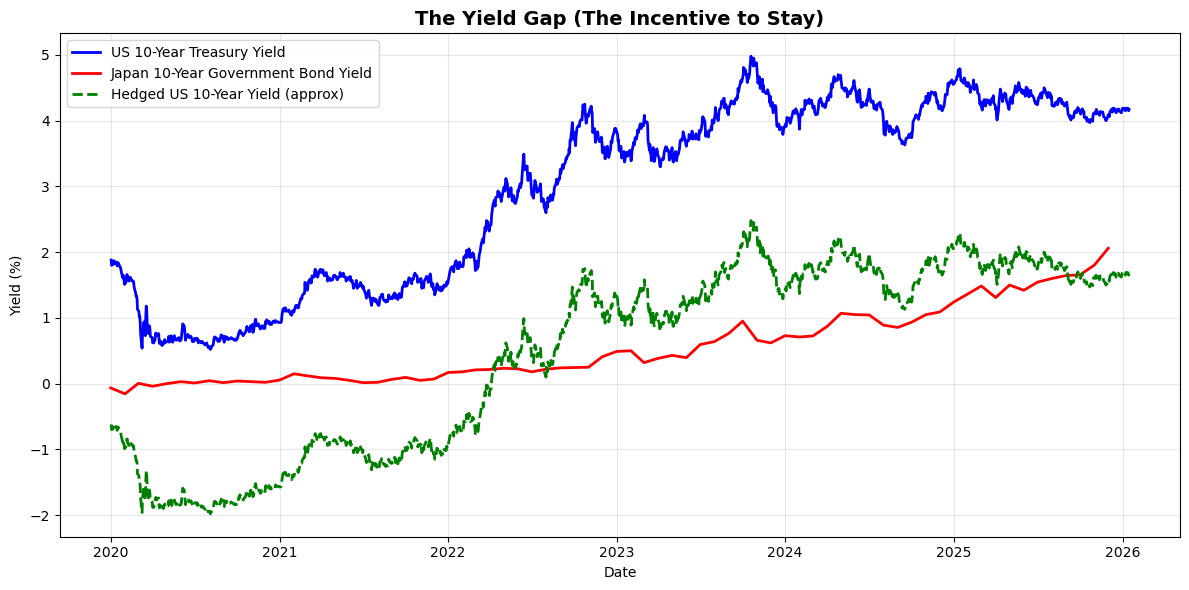

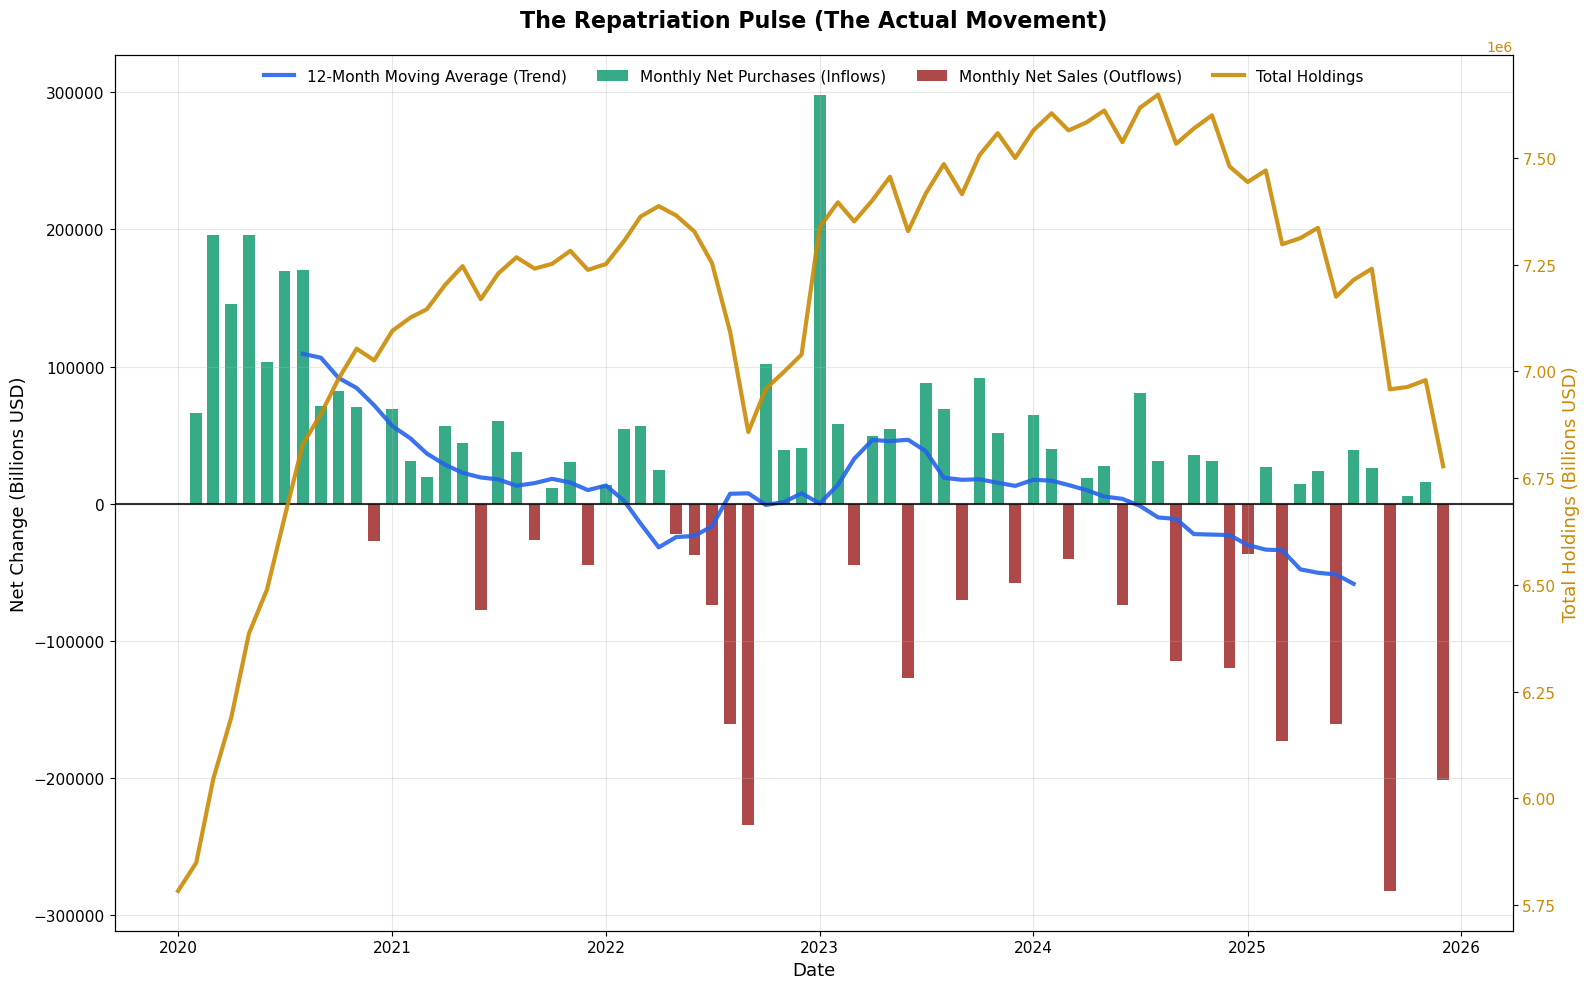

📊 Charts generated successfully!

🔍 Key Insights to Look For:
Chart 1 - The Yield Gap:
- When hedged US yields (green dashed) fall below Japan yields (red), expect capital repatriation
- Current convergence suggests weakening of the 'Gravity Well'

Chart 2 - The Repatriation Pulse:
- Green bars = Net purchases (capital flowing TO US)
- Red bars = Net sales (capital flowing FROM US - repatriation)
- Navy line = 12-month moving average (structural trend)
- Orange line = Total holdings level
- When moving average crosses below zero = 'Gravity Well' failure

⚠️ Watch for: Sustained red bars + declining moving average coinciding with BoJ rate hikes

💡 Analysis Notes:
- Hedging cost approximated at 2.5% (real-world varies with FX volatility)
- Moving average smooths monthly volatility to reveal structural shifts


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import pandas_datareader.data as web
import warnings
import matplotlib.pyplot as plt
from datetime import datetime
warnings.filterwarnings('ignore')

# Set date range for data retrieval
start_date = datetime(2020, 1, 1)
end_date = datetime.now()

# Fetch data from FRED using pandas datareader
try:
    us_10y = web.DataReader('DGS10', 'fred', start_date, end_date).dropna()
    print("✓ Successfully fetched US 10-Year Treasury Yield data")
except Exception as e:
    print(f"✗ Error fetching US 10Y data: {e}")

try:
    japan_10y = web.DataReader('IRLTLT01JPM156N', 'fred', start_date, end_date).dropna()
    print("✓ Successfully fetched Japan 10-Year Government Bond Yield data")
except Exception as e:
    print(f"✗ Error fetching Japan 10Y data: {e}")

# Try multiple symbols for Japanese Treasury holdings
japan_treasury_holdings = None
treasury_symbols = ['TICGJ', 'JPNASSETS', 'TICS3FJ']  # Multiple potential symbols

for symbol in treasury_symbols:
    try:
        japan_treasury_holdings = web.DataReader(symbol, 'fred', start_date, end_date).dropna()
        print(f"✓ Successfully fetched Japanese Treasury holdings data using symbol: {symbol}")
        break
    except Exception as e:
        print(f"✗ Failed to fetch data with symbol {symbol}: {e}")
        continue

if japan_treasury_holdings is None:
    print("⚠️ Unable to fetch Japanese Treasury holdings data. Creating sample data for demonstration.")
    # Create sample data for demonstration purposes
    import pandas as pd
    sample_dates = pd.date_range(start=start_date, end=end_date, freq='M')
    japan_treasury_holdings = pd.Series(
        np.random.normal(1100, 50, len(sample_dates)),  # Sample around $1.1T with variation
        index=sample_dates,
        name='Japanese Treasury Holdings (Sample)'
    )

# Convert to pandas Series for easier handling
us_10y = us_10y.squeeze()
japan_10y = japan_10y.squeeze()
japan_treasury_holdings = japan_treasury_holdings.squeeze()

# Create Chart 1: The Yield Gap (The Incentive to Stay)
fig1, ax1 = plt.subplots(1, 1, figsize=(12, 6))

# Chart 1: Yield Comparison
ax1.plot(us_10y.index, us_10y.values, label='US 10-Year Treasury Yield', linewidth=2, color='blue')
ax1.plot(japan_10y.index, japan_10y.values, label='Japan 10-Year Government Bond Yield', linewidth=2, color='red')

# Add hedging cost approximation (simplified)
# Note: For a real implementation, you'd need actual FX forward rates
hedging_cost_approx = 2.5  # Approximate hedging cost in percentage points
hedged_us_yield = us_10y - hedging_cost_approx
ax1.plot(hedged_us_yield.index, hedged_us_yield.values, 
         label='Hedged US 10-Year Yield (approx)', linewidth=2, color='green', linestyle='--')

ax1.set_title('The Yield Gap (The Incentive to Stay)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Yield (%)')
ax1.set_xlabel('Date')
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
# Save Chart 1
fig1.savefig('chart1_yield_gap.png', dpi=300, bbox_inches='tight', facecolor='white')
fig1.savefig('chart1_yield_gap.pdf', bbox_inches='tight', facecolor='white')
plt.show()

# Chart 2: The Repatriation Pulse (Enhanced)
# Calculate month-over-month changes for net flows
holdings_change = japan_treasury_holdings.diff()

# Calculate 12-month moving average for trend analysis
moving_avg_12m = holdings_change.rolling(window=12, center=True).mean()

# Create enhanced Chart 2
fig2, ax2 = plt.subplots(1, 1, figsize=(16, 10))

# Net Flow Bars (Monthly) - Create separate bars for positive and negative flows
positive_mask = holdings_change >= 0
negative_mask = holdings_change < 0

# Plot positive flows (emerald)
ax2.bar(holdings_change[positive_mask].index, holdings_change[positive_mask].values, 
        color='#059669', alpha=0.8, width=20, label='Monthly Net Purchases (Inflows)')

# Plot negative flows (burgundy)  
ax2.bar(holdings_change[negative_mask].index, holdings_change[negative_mask].values, 
        color='#991b1b', alpha=0.8, width=20, label='Monthly Net Sales (Outflows)')

# 12-Month Moving Average (steel blue)
ax2.plot(moving_avg_12m.index, moving_avg_12m.values, 
         color='#2563eb', linewidth=3, label='12-Month Moving Average (Trend)', alpha=0.9)

# Zero line for reference
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1.5)

# Set up primary axis with more space
ax2.set_title('The Repatriation Pulse (The Actual Movement)', 
              fontsize=16, fontweight='bold', pad=20)
ax2.set_ylabel('Net Change (Billions USD)', fontsize=13)
ax2.set_xlabel('Date', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=11)

# Create secondary axis for total holdings with better formatting
ax2_twin = ax2.twinx()
ax2_twin.plot(japan_treasury_holdings.index, japan_treasury_holdings.values, 
              color='#ca8a04', linewidth=3, alpha=0.9, label='Total Holdings')
ax2_twin.set_ylabel('Total Holdings (Billions USD)', fontsize=13, color='#ca8a04')
ax2_twin.tick_params(axis='y', labelcolor='#ca8a04', labelsize=11)

# Combine legends from both axes with horizontal layout at top
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, 
           loc='upper center', bbox_to_anchor=(0.5, 1.00), 
           ncol=4, fontsize=11, frameon=False)

plt.tight_layout()
# Save Chart 2
fig2.savefig('chart2_repatriation_pulse.png', dpi=300, bbox_inches='tight', facecolor='white')
fig2.savefig('chart2_repatriation_pulse.pdf', bbox_inches='tight', facecolor='white')
plt.show()

print("📊 Charts generated successfully!")
print("\n🔍 Key Insights to Look For:")
print("Chart 1 - The Yield Gap:")
print("- When hedged US yields (green dashed) fall below Japan yields (red), expect capital repatriation")
print("- Current convergence suggests weakening of the 'Gravity Well'")
print("\nChart 2 - The Repatriation Pulse:")
print("- Green bars = Net purchases (capital flowing TO US)")
print("- Red bars = Net sales (capital flowing FROM US - repatriation)")
print("- Navy line = 12-month moving average (structural trend)")
print("- Orange line = Total holdings level")
print("- When moving average crosses below zero = 'Gravity Well' failure")
print("\n⚠️ Watch for: Sustained red bars + declining moving average coinciding with BoJ rate hikes")

print("\n💡 Analysis Notes:")
print("- Hedging cost approximated at 2.5% (real-world varies with FX volatility)")
print("- Moving average smooths monthly volatility to reveal structural shifts")